In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'cv2'

In [12]:
img=cv2.imread('../Images/road.bmp',cv2.IMREAD_GRAYSCALE)

In [13]:
print(img.shape)

(256, 256)


In [ ]:
print(type(img))

### Standard Average Filter

In [ ]:
def standard_average_filter(image,kernel_size=3):
    
    height, width = image.shape
    
    # Create output image (same size as input)
    filtered_image = np.zeros((height, width), dtype=np.uint8)
    pad = kernel_size // 2 
    
    # Create padded image (pad with zeros)
    padded_image = np.zeros((height + 2*pad, width + 2*pad), dtype=np.float32)
    padded_image[pad:height+pad, pad:width+pad] = image.astype(np.float32)
    
    # print(f"Original image shape: {image.shape}")
    # print(f"Padded image shape: {padded_image.shape}")
    # print(f"Kernel size: {kernel_size}x{kernel_size}")
    for i in range(height):
        for j in range(width):
            # Extract the 3x3 neighborhood
            neighborhood = padded_image[i:i+kernel_size, j:j+kernel_size]

            total_sum = 0
            pixel_count = 0
            
            for ki in range(kernel_size):
                for kj in range(kernel_size):
                    total_sum += neighborhood[ki, kj]
                    pixel_count += 1
            
            # Average = sum / number of pixels
            average_value = total_sum / pixel_count
            filtered_image[i, j] = int(average_value)
    
    return filtered_image

filtered_img = standard_average_filter(img)


Applying standard 3x3 average filter...
Original image shape: (256, 256)
Padded image shape: (258, 258)
Kernel size: 3x3


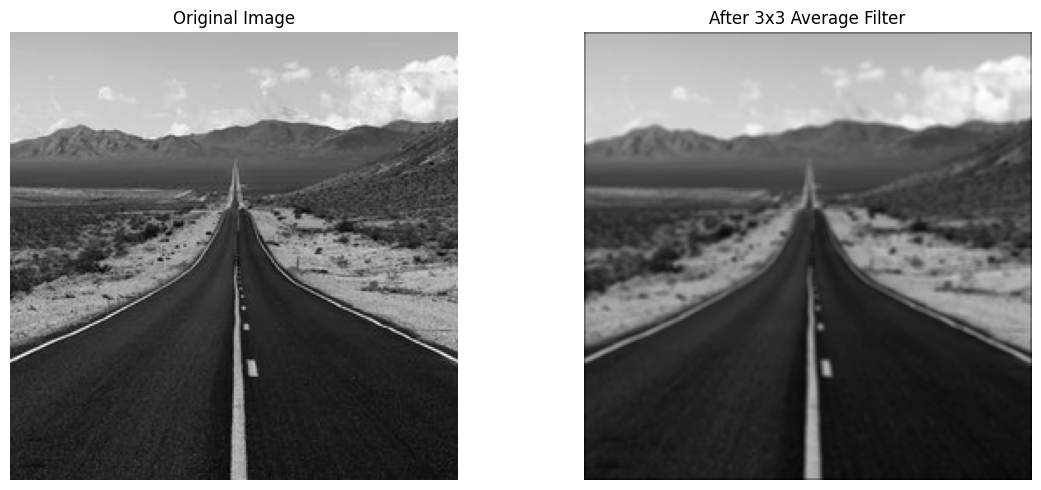

In [21]:
plt.figure(figsize=(12, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Filtered image
plt.subplot(1, 2, 2)
plt.imshow(filtered_img, cmap='gray')
plt.title('After 3x3 Average Filter')
plt.axis('off')

plt.tight_layout()
plt.show()

# # Show the difference
# print(f"Original image data type: {img.dtype}")
# print(f"Filtered image data type: {filtered_img.dtype}")
# print(f"Original image range: [{img.min()}, {img.max()}]")
# print(f"Filtered image range: [{filtered_img.min()}, {filtered_img.max()}]")

### Weighted Average Filter

In [ ]:
def weighted_average_filter(image, kernel_size=3):
   
   
    weights = np.array([[1, 2, 1],
                           [2, 4, 2],
                           [1, 2, 1]], dtype=np.float32)
    weight_sum = 16.0  # Sum of all weights

    height, width = image.shape
    # Create output image
    filtered_image = np.zeros((height, width), dtype=np.uint8)
    pad = kernel_size // 2
    padded_image = np.pad(image, pad, mode='constant', constant_values=0).astype(np.float32)

    print(f"Applying weighted filter to {height}x{width} image...")
    
    # Apply the weighted filter
    for i in range(height):
        for j in range(width):
            # Extract the neighborhood
            neighborhood = padded_image[i:i+kernel_size, j:j+kernel_size]
            
            weighted_sum = 0.0
            
            for ki in range(kernel_size):
                for kj in range(kernel_size):
                    weighted_sum += neighborhood[ki, kj] * weights[ki, kj]
            
            weighted_average = weighted_sum / weight_sum
            filtered_image[i, j] = int(round(weighted_average))
    
    return filtered_image

weighted_filtered_img = weighted_average_filter(img)

Weighted kernel:
[[1. 2. 1.]
 [2. 4. 2.]
 [1. 2. 1.]]
Weight sum: 16.0
Normalized weights:
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]
Applying weighted filter to 256x256 image...


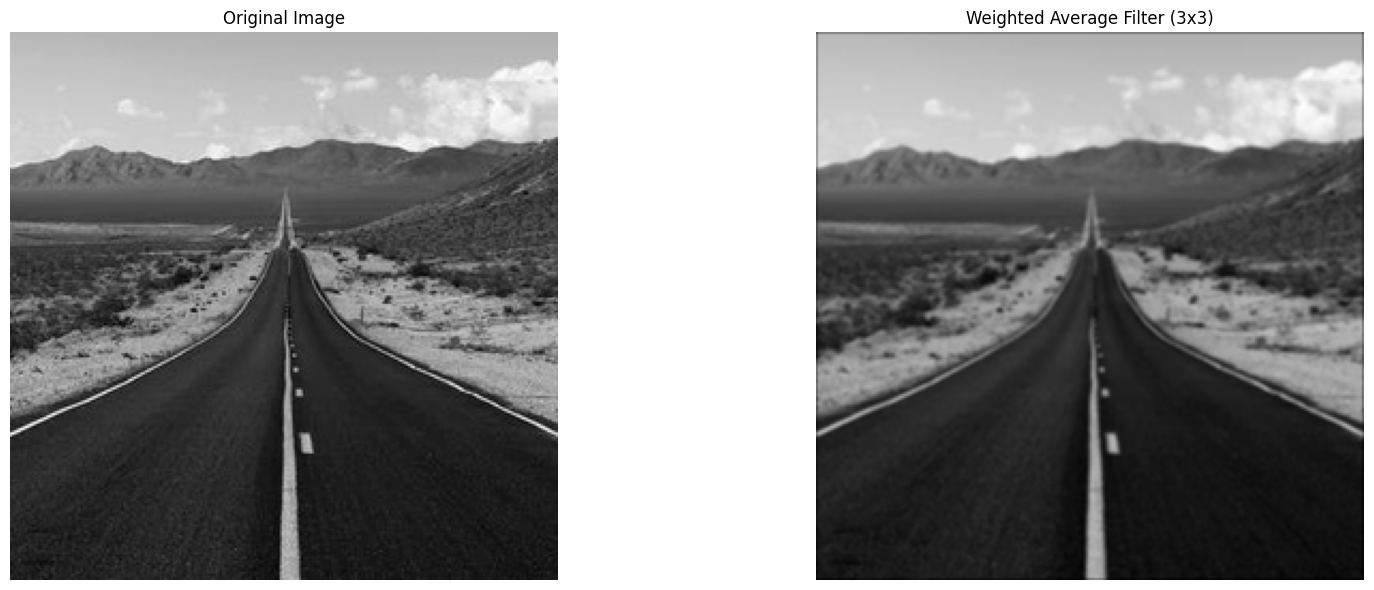

In [35]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(weighted_filtered_img, cmap='gray')
plt.title('Weighted Average Filter (3x3)')
plt.axis('off')

plt.tight_layout()
plt.show()


## Median Filter

In [ ]:
def median_filter(image, kernel_size=3):

    height, width = image.shape
    # Create output image
    filtered_image = np.zeros((height, width), dtype=np.uint8)
    pad = kernel_size // 2
    
    # Create padded image with reflection to handle borders
    padded_image = np.pad(image, pad, mode='constant', constant_values=0).astype(np.float32)
    # print(f"Applying median filter to {height}x{width} image...")
    # print(f"Kernel size: {kernel_size}x{kernel_size}")
    # print(f"Total pixels in neighborhood: {kernel_size * kernel_size}")
    # print(f"Median position: {(kernel_size * kernel_size) // 2 + 1}")
    
    # Apply the median filter
    for i in range(height):
        for j in range(width):
            
            neighborhood = padded_image[i:i+kernel_size, j:j+kernel_size]
            
            # Flatten the neighborhood to 1D array for sorting
            neighborhood_flat = []
            for ki in range(kernel_size):
                for kj in range(kernel_size):
                    neighborhood_flat.append(neighborhood[ki, kj])
            
            
            n = len(neighborhood_flat)
            for sort_i in range(n):
                for sort_j in range(0, n - sort_i - 1):
                    if neighborhood_flat[sort_j] > neighborhood_flat[sort_j + 1]:
                        # Swap elements
                        neighborhood_flat[sort_j], neighborhood_flat[sort_j + 1] = \
                            neighborhood_flat[sort_j + 1], neighborhood_flat[sort_j]
            
            # Find median (middle value after sorting)
            median_index = n // 2
            median_value = neighborhood_flat[median_index]
            
            # Assign median value to output image
            filtered_image[i, j] = int(median_value)
    
    return filtered_image

median_filtered_img = median_filter(img)


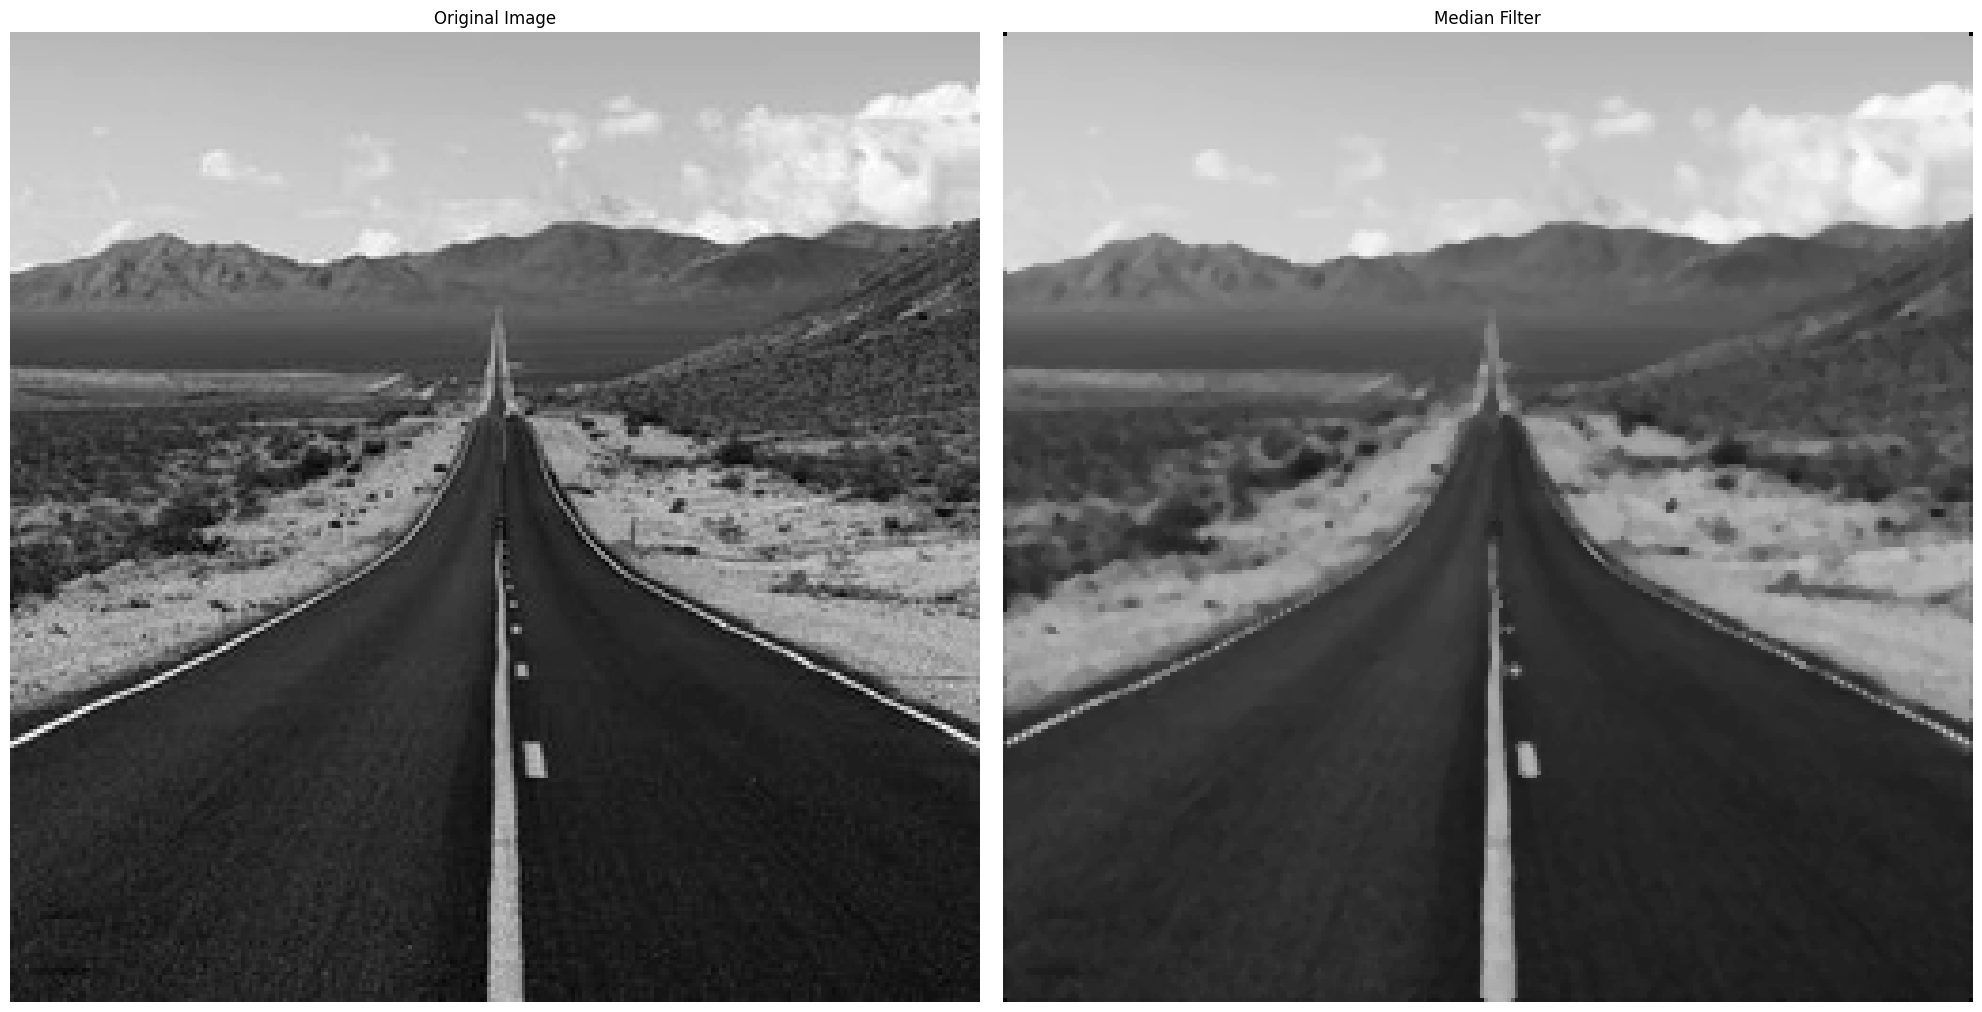

In [47]:
plt.figure(figsize=(20, 10))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')


# Median filtered image
plt.subplot(1, 2, 2)
plt.imshow(median_filtered_img, cmap='gray')
plt.title('Median Filter')
plt.axis('off')

plt.tight_layout()
plt.show()


## Laplacian Filter

In [ ]:
def laplacian_filter(image):
    """
    kernel:
    [ 0 -1  0]
    [-1  4 -1]
    [ 0 -1  0]
    """
    height, width = image.shape
    filtered_image = np.zeros((height, width), dtype=np.float32)
    
    # Laplacian kernel
    laplacian_kernel = np.array([[ 0, -1,  0],
                                [-1,  4, -1],
                                [ 0, -1,  0]], dtype=np.float32)
    padded_image = np.pad(image, 1, mode='constant', constant_values=0).astype(np.float32)

    # Apply Laplacian filter
    for i in range(height):
        for j in range(width):
            neighborhood = padded_image[i:i+3, j:j+3]
            
            # Convolution with Laplacian kernel
            laplacian_value = 0.0
            for ki in range(3):
                for kj in range(3):
                    laplacian_value += neighborhood[ki, kj] * laplacian_kernel[ki, kj]
            
            filtered_image[i, j] = laplacian_value
    
    # Normalize to 0-255 range for display
    filtered_image = filtered_image - filtered_image.min()
    filtered_image = (filtered_image / filtered_image.max() * 255).astype(np.uint8)
    
    return filtered_image

laplacian_filtered_img = laplacian_filter(img)

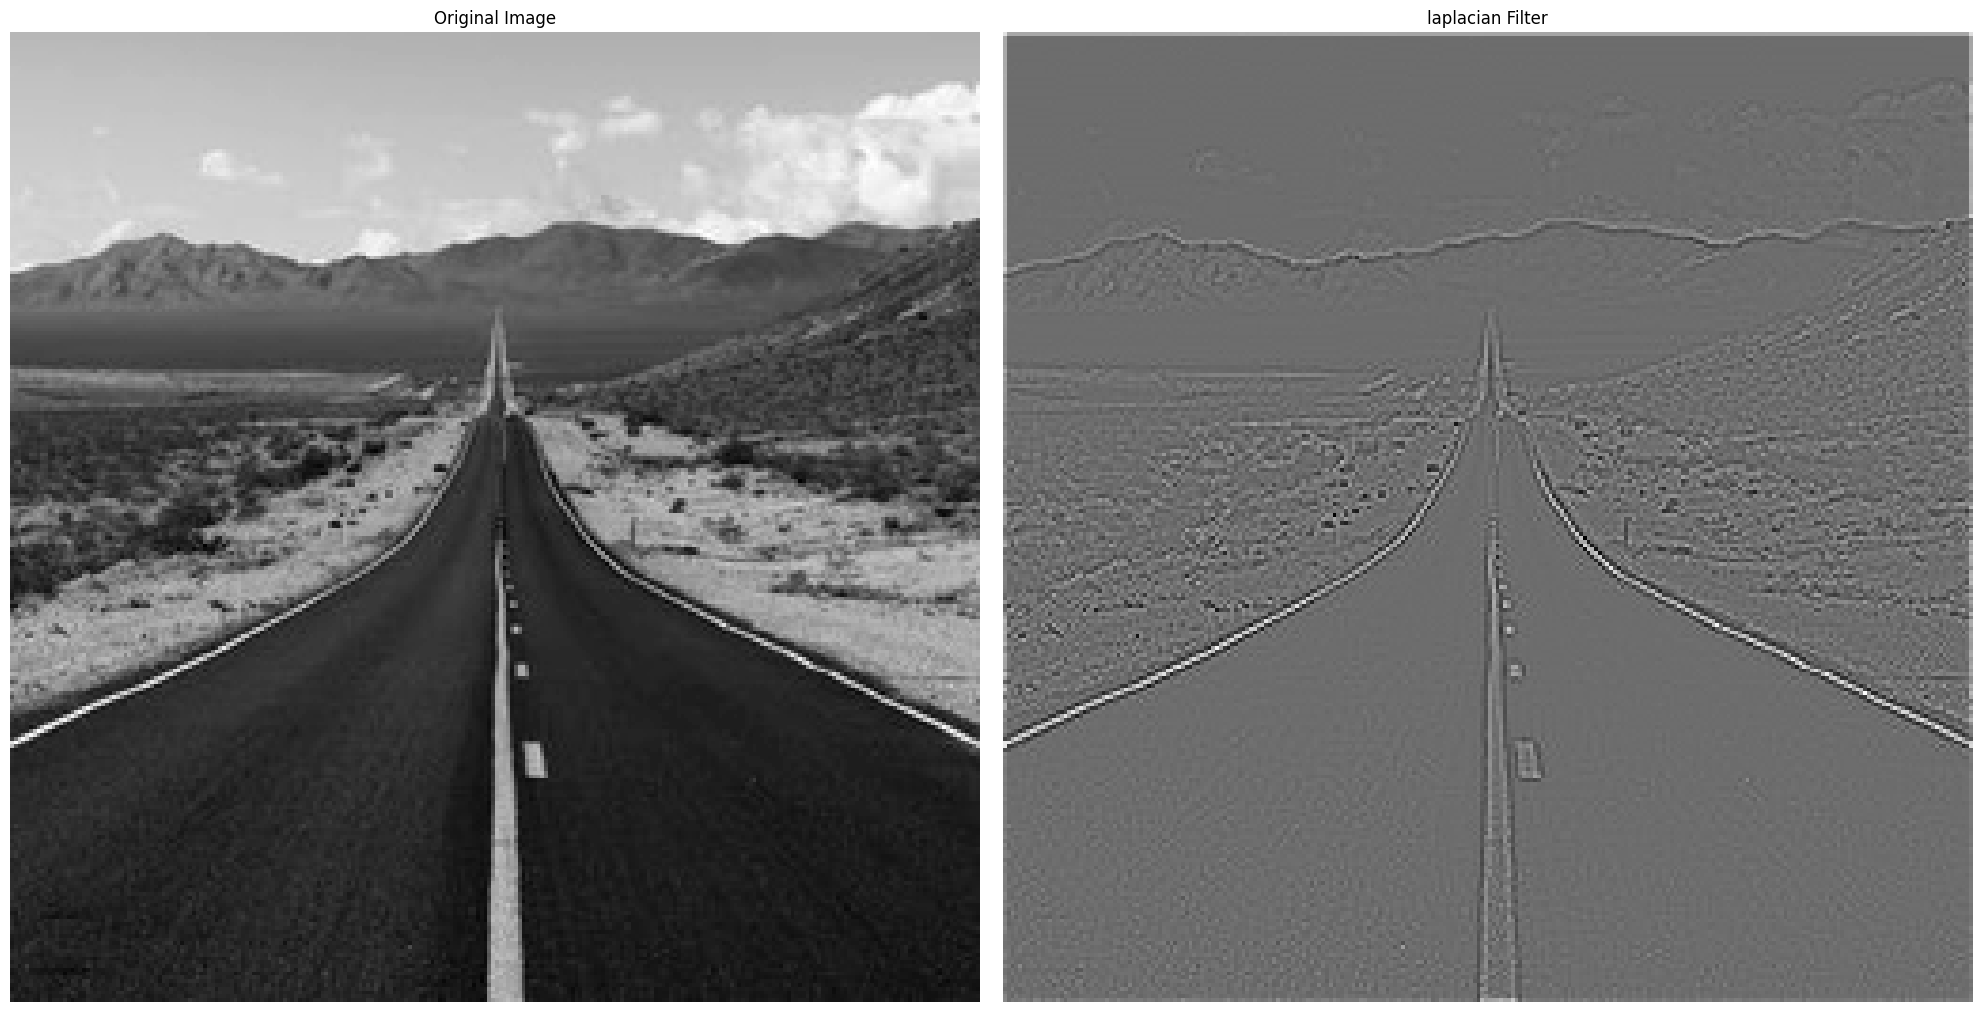

In [43]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(laplacian_filtered_img, cmap='gray')
plt.title('laplacian Filter')
plt.axis('off')

plt.tight_layout()
plt.show()


## Highboost Filter

In [ ]:
def highboost_filter(image, k=1.5):

    height, width = image.shape
    # First apply a lowpass filter (using weighted average for smoothing)
    lowpass_img = np.zeros((height, width), dtype=np.float32)
    # Smoothing kernel (normalized)
    smooth_kernel = np.array([[1, 2, 1],
                             [2, 4, 2],
                             [1, 2, 1]], dtype=np.float32) / 16.0
    
    padded_image = np.pad(image, 1, mode='constant', constant_values=0).astype(np.float32)
    # Apply smoothing
    for i in range(height):
        for j in range(width):
            neighborhood = padded_image[i:i+3, j:j+3]
            
            smooth_value = 0.0
            for ki in range(3):
                for kj in range(3):
                    smooth_value += neighborhood[ki, kj] * smooth_kernel[ki, kj]
            
            lowpass_img[i, j] = smooth_value
    
    # Calculate high-frequency components
    high_freq = image.astype(np.float32) - lowpass_img
    highboost_img = image.astype(np.float32) + k * high_freq
    highboost_img = np.clip(highboost_img, 0, 255).astype(np.uint8)
    
    return highboost_img

highboost_filtered_img = highboost_filter(img, k=1.5)


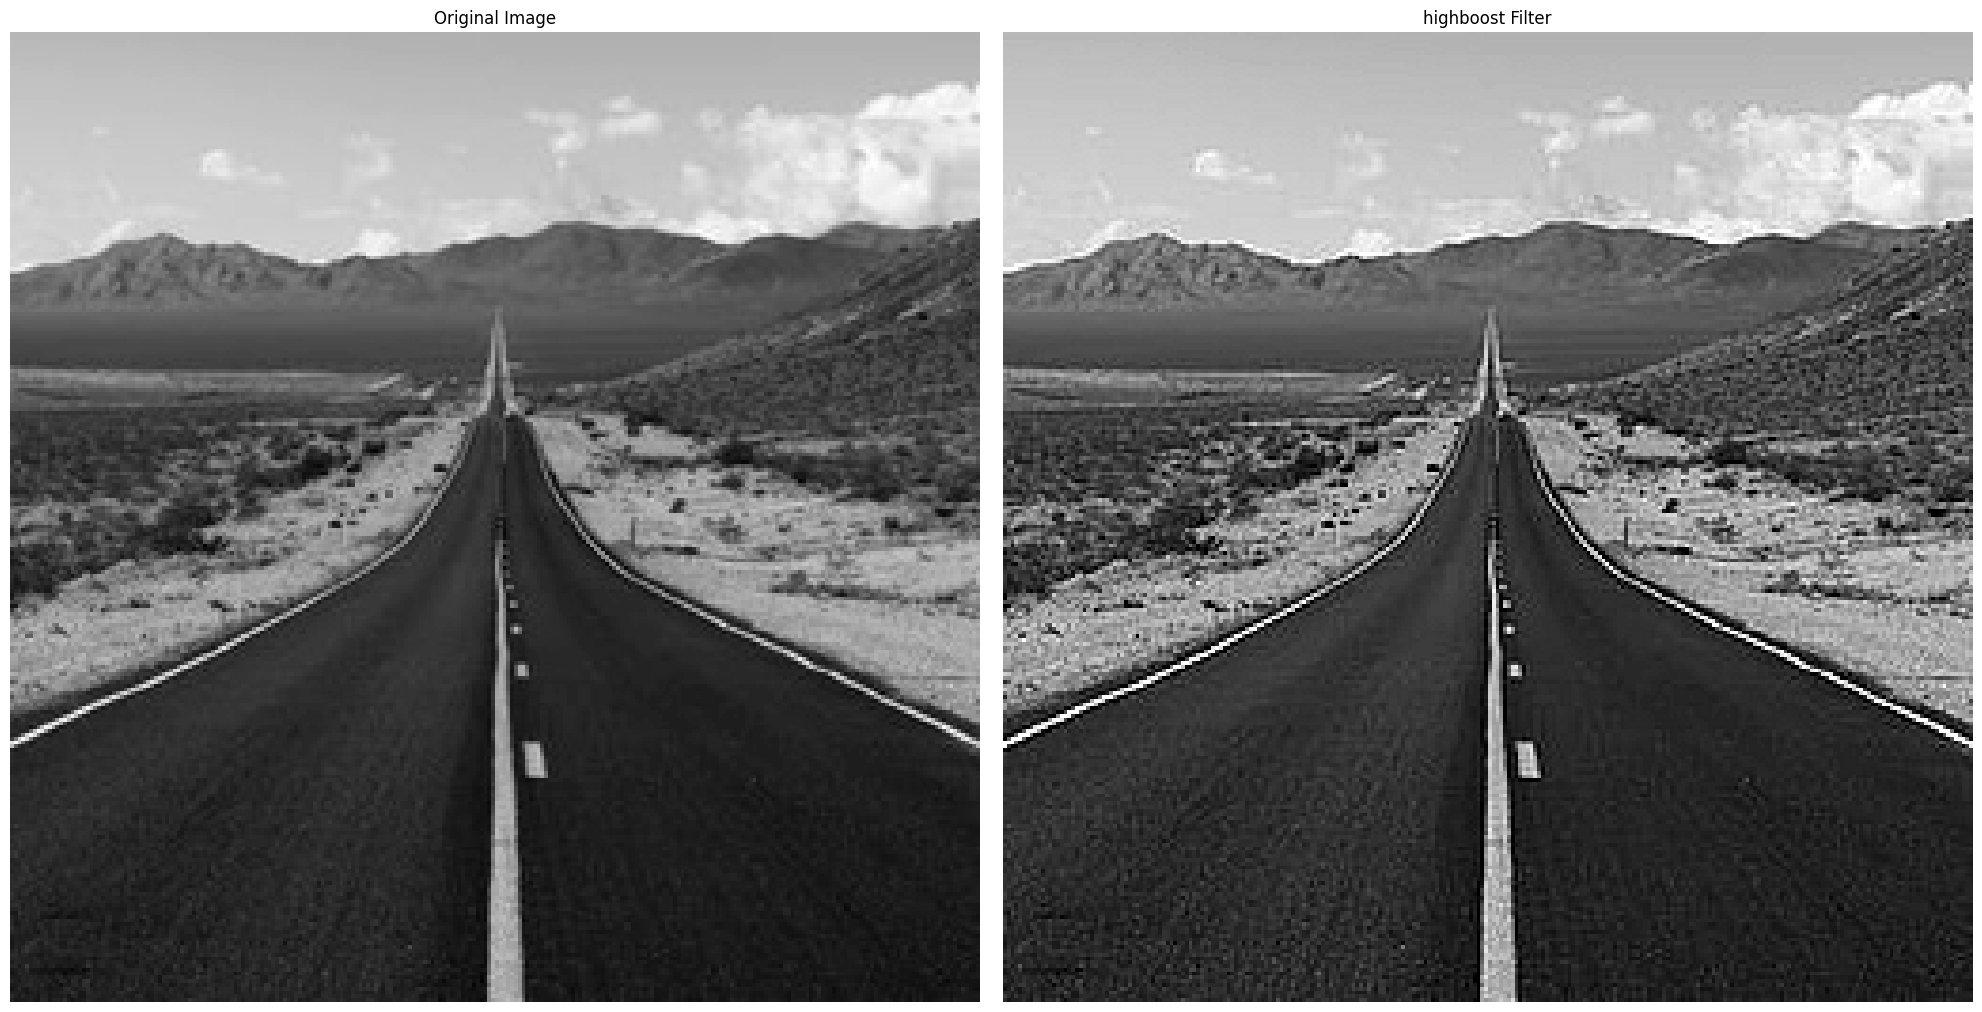

In [49]:
plt.figure(figsize=(20, 10))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')


plt.subplot(1, 2, 2)
plt.imshow(highboost_filtered_img, cmap='gray')
plt.title('highboost Filter')
plt.axis('off')

plt.tight_layout()
plt.show()
